<a href="https://colab.research.google.com/github/asegura4488/EDCO_IntroCienciaDatos/blob/main/Semana4/RegresionLinealConceptos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
from google.colab import drive
from google.colab import files
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [13]:
# Necesitamos explorar la estructura de directorios
import os
# Necesito ir a la carpeta del curso
os.chdir('/content/drive/MyDrive/EDCO_IntroCienciaDatos/Semana5/')

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [15]:
# Problemas de regresion
data = pd.read_csv('Datos/DatosRegresion.csv')
data

,X0,X1,Y
0,5.488135,6.207617,25.523276
1,7.151894,7.460697,32.167177
2,6.027634,10.499409,43.066154
3,5.448832,15.011900,38.069097
4,4.236548,6.670149,21.101511
...,...,...,...
495,2.716528,1.953527,5.693810
496,4.554441,10.298444,28.084859
497,4.017135,18.768240,51.312559
498,2.484135,4.572931,18.596668


In [16]:
X = np.array(data[['X0','X1']])
Y = np.array(data['Y'])

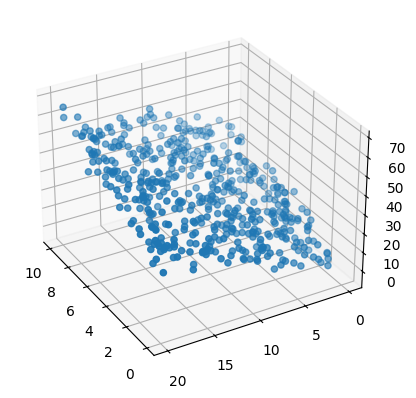

In [17]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d', elev=30, azim=150)
ax.scatter(X[:,0], X[:,1], Y)
plt.show()

In [47]:
# Queremos encontra el modelo, que es una aproximacion lineal a la nube de datos
XTrain, XTest, YTrain, YTest = train_test_split(X, Y, test_size=0.2)

In [48]:
# Modelo
Model = LinearRegression()
Model.fit(XTrain, YTrain)

LinearRegression()

In [49]:
Model.intercept_

np.float64(3.003873848417385)

In [50]:
Model.coef_[0]

np.float64(2.498791584538632)

In [51]:
Model.coef_[1]

np.float64(1.5199503918579722)

In [52]:
params = np.array([Model.intercept_,Model.coef_[0],Model.coef_[1]])
params

array([3.00387385, 2.49879158, 1.51995039])

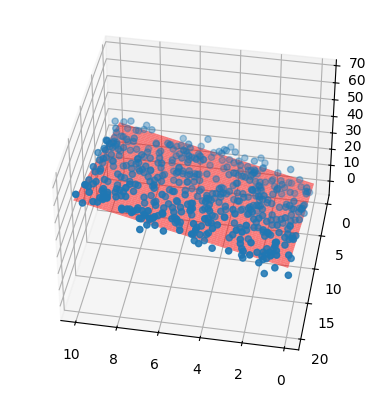

In [53]:
x0 = np.linspace(min(X[:,0]),max(X[:,0]),100)
x1 = np.linspace(min(X[:,1]),max(X[:,1]),100)
xx0,xx1 = np.meshgrid(x0,x1)

YModelo = params[0] + params[1]*xx0 + params[2]*xx1


fig = plt.figure()
ax = fig.add_subplot(projection='3d', elev=40, azim=100)
ax.scatter(X[:,0], X[:,1], Y)
ax.plot_surface(xx0,xx1,YModelo, alpha=0.5,color='r')
plt.show()

In [54]:
# cualitatitamente: OK

In [55]:
X[20]

array([ 9.78618342, 10.87356108])

In [56]:
Y[20]

np.float64(46.42102636233411)

In [57]:
params[0] + params[1]*X[20][0] + params[2]*X[20][1]

np.float64(43.98478004809302)

In [58]:
for i in range(30):
  y_pred = params[0] + params[1]*X[i][0] + params[2]*X[i][1]
  print(y_pred,Y[i], y_pred-Y[i])

26.152848660829285 25.523276004803105 0.6295726560261805
32.21485529949112 32.167176998298295 0.04767830119282479
34.024254952741 43.066153902817206 -9.041898950076202
39.436712955261235 38.06909698179163 1.3676159734696043
23.72842038813213 21.101510767239965 2.626909620892164
47.23693118004162 46.978871944507056 0.2580592355345672
40.15189452185937 35.21366946229466 4.938225059564708
26.767559234101327 27.718803144143926 -0.9512439100425993
34.79427889386983 32.87556865749913 1.9187102363706998
26.14735519822526 17.01346561021458 9.133889588010678
25.968016482580204 25.63902985867153 0.3289866239086727
26.813179915946478 25.088937195176527 1.7242427207699507
39.69635401897621 31.241923285538864 8.454430733437345
46.81956979840814 46.21967961852869 0.599890179879452
23.69878601435813 30.89421412229972 -7.195428107941588
26.780411939907893 29.10060331558746 -2.320191375679567
9.7385662280924 12.712806508454984 -2.974240280362583
34.196592151883415 27.3589559567252 6.837636195158215
43.

In [59]:
# Vamos a evaluar el modelo con los datos de entrenamiento
YPred = Model.predict(XTrain)

In [60]:
mean_squared_error(YTrain, YPred)

20.744439388876867

In [61]:
mean_absolute_error(YTrain, YPred)

3.5962369276121238

In [62]:
r2_score(YTrain, YPred)

0.8632418467140368

In [63]:
# Nos estamos engañando, debemos evaluar las metricas en datos que no haya visto el modelo
YPred = Model.predict(XTest)

In [64]:
mean_squared_error(YTest, YPred)

26.584588142635344

In [65]:
mean_absolute_error(YTest, YPred)

4.092076899052347

In [66]:
r2_score(YTest, YPred)

0.7973351989572691

In [69]:
mean_ = []
for i in range(1000):
  XTrain, XTest, YTrain, YTest = train_test_split(X, Y, test_size=0.2)
  Model = LinearRegression()
  Model.fit(XTrain, YTrain)
  YPred = Model.predict(XTest)
  mean = mean_squared_error(YTest, YPred)
  r2 = r2_score(YTest, YPred)
  mean_.append(r2)

(array([ 1.,  0.,  0.,  0.,  0.,  0.,  1.,  1.,  2.,  4.,  0.,  0.,  0.,
         1.,  0.,  0.,  1.,  1.,  1.,  1.,  3.,  1.,  0.,  1.,  2.,  1.,
         1.,  7.,  0.,  5.,  3.,  5.,  2.,  6.,  5., 11.,  9.,  9., 15.,
         9.,  9., 10., 14., 12.,  6., 17., 12., 13., 18., 22., 20., 28.,
        28., 23., 28., 26., 11., 32., 25., 20., 30., 22., 23., 28., 23.,
        27., 25., 27., 25., 15., 27., 24., 25., 16., 17., 24., 14., 12.,
        15., 13., 17.,  7.,  9.,  6.,  9.,  3.,  5.,  8.,  3.,  3.,  3.,
         3.,  2.,  0.,  2.,  2.,  0.,  1.,  0.,  2.]),
 array([0.75616772, 0.75772502, 0.75928232, 0.76083962, 0.76239692,
        0.76395422, 0.76551152, 0.76706882, 0.76862612, 0.77018342,
        0.77174072, 0.77329802, 0.77485532, 0.77641261, 0.77796991,
        0.77952721, 0.78108451, 0.78264181, 0.78419911, 0.78575641,
        0.78731371, 0.78887101, 0.79042831, 0.79198561, 0.79354291,
        0.79510021, 0.79665751, 0.79821481, 0.7997721 , 0.8013294 ,
        0.8028867 , 0.8044

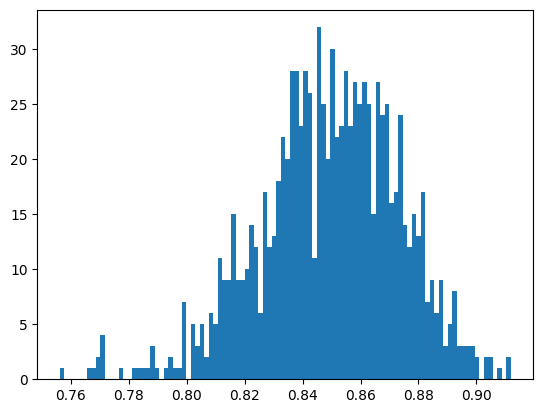

In [70]:
plt.hist(mean_, bins=100)

In [71]:
# Como averiguamos si el modelo esta sesgado
# lo vamos a averiguar con la distribucion de residuales (homocedasticidad)

In [75]:
residuales = YTest - Model.predict(XTest)
np.mean(residuales)

np.float64(0.24885094914001368)

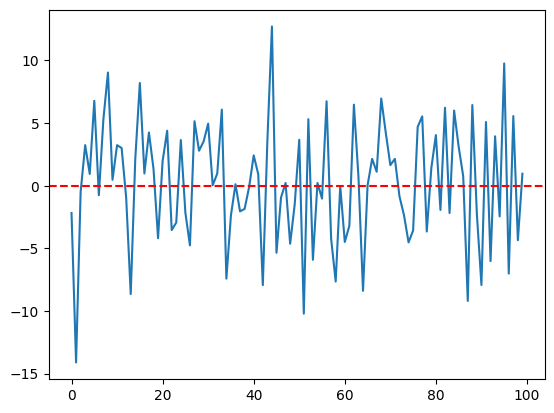

In [76]:
plt.plot(residuales)
plt.axhline(y=0,color='r',linestyle='--')